In [1]:
import pylidc as pl
import numpy as np
import pandas as pd
import os
import sys
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm import tqdm
from skimage.draw import polygon
import SimpleITK as sitk
from radiomics import featureextractor
import ast
import glob
import matplotlib.pyplot as plt

import os, ast
import pydicom
import numpy as np
import SimpleITK as sitk
from skimage.draw import polygon
from tqdm import tqdm
import pickle

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(src_path)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import shap
from sklearn.preprocessing import LabelEncoder

from Extension import plot_patient_tumours_3d, assign_tumour_ids_by_overlap, bootstrap_ci, get_friendly_feature_names


/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Script - For each of the 158 patients LIDC folders extract the xml and append to the patient nodule

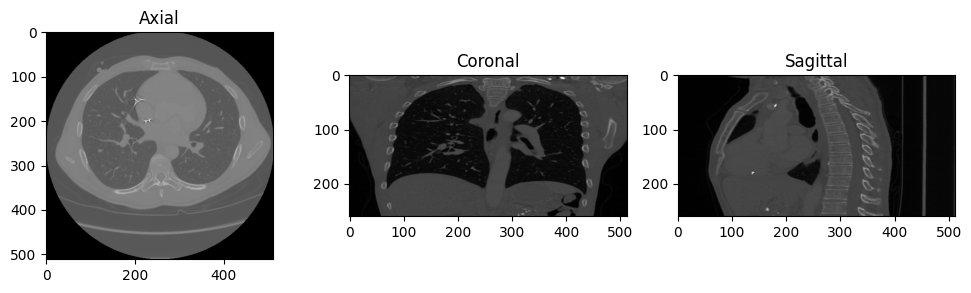

In [2]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# Path to a single CT series (change this to another patient/series as needed)
dicom_folder = "../data/Extension/DICOM_DATA_120_PATIENTS/New_manifest/manifest-1747751008571/LIDC-IDRI/LIDC-IDRI-0068/01-01-2000-NA-CT CHEST W CONT-80168/4.000000-Recon 3 CT CHEST-26125"

# Load all .dcm slices
slices = []
for fname in os.listdir(dicom_folder):
    if fname.endswith(".dcm"):
        path = os.path.join(dicom_folder, fname)
        slices.append(pydicom.dcmread(path))

# Sort slices by InstanceNumber
slices = sorted(slices, key=lambda x: int(x.InstanceNumber))

# Build 3D numpy volume
volume = np.stack([s.pixel_array for s in slices])
volume = volume.astype(np.int16)

# Show center slices in 3 planes
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(volume[volume.shape[0]//2], cmap="gray")  # Axial
axes[0].set_title("Axial")

axes[1].imshow(volume[:, volume.shape[1]//2, :], cmap="gray")  # Coronal
axes[1].set_title("Coronal")

axes[2].imshow(volume[:, :, volume.shape[2]//2], cmap="gray")  # Sagittal
axes[2].set_title("Sagittal")

plt.tight_layout()
plt.show()


In [3]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

# --- Setup ---
base_dir = "../data/Extension/DICOM_DATA_120_PATIENTS/New_manifest/manifest-1747751008571/LIDC-IDRI"
ns = {"lidc": "http://www.nih.gov"}
roi_records = []

all_patients = sorted(os.listdir(base_dir))
print("🔍 Total patient folders found:", len(all_patients))

missing_xml_patients = []
malformed_roi_patients = set()
parsed_patients = set()

# --- Traverse each patient folder ---
for patient_id in all_patients:
    patient_path = os.path.join(base_dir, patient_id)
    if not os.path.isdir(patient_path):
        continue

    # --- Find all .xml files ---
    xml_files = []
    for root_dir, _, files in os.walk(patient_path):
        for file in files:
            if file.endswith(".xml"):
                xml_files.append(os.path.join(root_dir, file))

    # ✅ Check if no XMLs found
    if not xml_files:
        missing_xml_patients.append(patient_id)
        continue

    roi_found = False

    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
        except Exception as e:
            print(f"❌ Failed parsing XML for {patient_id}: {e}")
            continue

        # --- Find reading sessions & nodules ---
        for reading_session in root.findall(".//lidc:readingSession", ns):
            for nodule in reading_session.findall("lidc:unblindedReadNodule", ns):
                nodule_id_elem = nodule.find("lidc:noduleID", ns)
                nodule_id = nodule_id_elem.text if nodule_id_elem is not None else "Unknown"

                for roi in nodule.findall("lidc:roi", ns):
                    z_elem = roi.find("lidc:imageZposition", ns)
                    if z_elem is None:
                        continue
                    z = float(z_elem.text)

                    x_coords = []
                    y_coords = []
                    for edge in roi.findall("lidc:edgeMap", ns):
                        x = edge.find("lidc:xCoord", ns)
                        y = edge.find("lidc:yCoord", ns)
                        if x is not None and y is not None:
                            x_coords.append(int(x.text))
                            y_coords.append(int(y.text))

                    if len(x_coords) == 0 or len(y_coords) == 0:
                        print(f"⚠️ Skipping ROI with no coords in {patient_id}, nodule {nodule_id}, z={z}")
                        malformed_roi_patients.add(patient_id)
                        continue

                    roi_records.append({
                        "PatientID": patient_id,
                        "Z": z,
                        "X_coords": x_coords,
                        "Y_coords": y_coords,
                        "NoduleID": nodule_id
                    })
                    roi_found = True

    if roi_found:
        parsed_patients.add(patient_id)

# --- Final DataFrame ---
df_roi = pd.DataFrame(roi_records)
unique_patients_in_df = df_roi["PatientID"].nunique()

print("\n✅ df_roi shape:", df_roi.shape)
print("🧬 Unique PatientIDs in df_roi:", unique_patients_in_df)
print("⚠️ Patients with no XML:", len(missing_xml_patients))
print("⚠️ Patients with malformed ROIs only:", len(malformed_roi_patients))
print("📦 Total patients with parsed XML:", len(parsed_patients))
print("📂 Example patients with no XML:", missing_xml_patients[:5])
print("📂 Example patients with malformed ROIs:", list(malformed_roi_patients)[:5])

# Optional: Save to CSV for inspection
# df_roi.to_csv("roi_debug_output.csv", index=False)


🔍 Total patient folders found: 158

✅ df_roi shape: (9068, 5)
🧬 Unique PatientIDs in df_roi: 157
⚠️ Patients with no XML: 0
⚠️ Patients with malformed ROIs only: 0
📦 Total patients with parsed XML: 157
📂 Example patients with no XML: []
📂 Example patients with malformed ROIs: []


### 158 Patients -> 157 Patients with valid XMLS

In [4]:
print("✅ Unique patients in df_roi:", df_roi["PatientID"].nunique())


✅ Unique patients in df_roi: 157


### Extract Diagnosis from Excel file. 

- If diagnosis is 0 (unkown) remove 
- If diagnosis is 1 (Benign) label it as '0'
- If diagnosis is 2 or 3 (Malignant) label it as '1'

In [5]:
df_diag = pd.read_excel("../data/Extension/tcia-diagnosis-data-2012-04-20.xls")
df_diag.rename(columns={df_diag.columns[0]: "PatientID"}, inplace=True)
df_diag["PatientID"] = df_diag["PatientID"].str.replace("LIDC-IDRI-", "").astype(str).str.zfill(4)
df_diag["PatientID"] = "LIDC-IDRI-" + df_diag["PatientID"]
df_diag = df_diag[["PatientID", df_diag.columns[1]]]  # Only keep relevant diagnosis col
df_diag.columns = ["PatientID", "Diagnosis"]

df_diag["Label"] = df_diag["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)

In [6]:
df_roi_labeled = df_roi.merge(df_diag, on="PatientID", how="left")
print("✅ Final shape:", df_roi_labeled.shape)
print("🔍 Missing labels:", df_roi_labeled["Label"].isna().sum())

✅ Final shape: (9068, 7)
🔍 Missing labels: 0


### Compute ROI for each Nodule

In [7]:
# Compute number of slices (ROIs) per PatientID + NoduleID
roi_counts = df_roi_labeled.groupby(["PatientID", "NoduleID"]).size().reset_index(name="NumROIs")

# Merge back into df_roi
df_roi_final = df_roi_labeled.merge(roi_counts, on=["PatientID", "NoduleID"], how="left")

### Keep only 'Good' Nodules
- Good nodule is those defined as NumROI >= 3
- Meaning that the segmentation of that nodule by one radiologist extends to at least 3 slices across the patient

In [8]:
df_main = pd.read_csv("../data/MAIN_DATAFRAME_PATIENT_COORDS_LABEL.csv")

# Keep nodules with 3+ ROI slices and known diagnosis
df_good = df_main[(df_main["NumROIs"] >= 3) & (df_main["Diagnosis"].isin([1, 2, 3]))]

# Assign binary label
df_good["Label"] = df_good["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)

print("✅ Good nodules:", df_good.shape)


✅ Good nodules: (6830, 8)


/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_62639/980591652.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["Label"] = df_good["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)


## Identify unique tumours and create 1 3D volume per unique tumour

In [9]:
df_good = pd.read_csv("../data/MAIN_DATAFRAME_PATIENT_GOOD_COORDS_LABEL.csv")
df_good_clean = assign_tumour_ids_by_overlap(df_good)

Assigning TumourIDs: 100%|██████████| 107/107 [00:03<00:00, 30.59it/s]


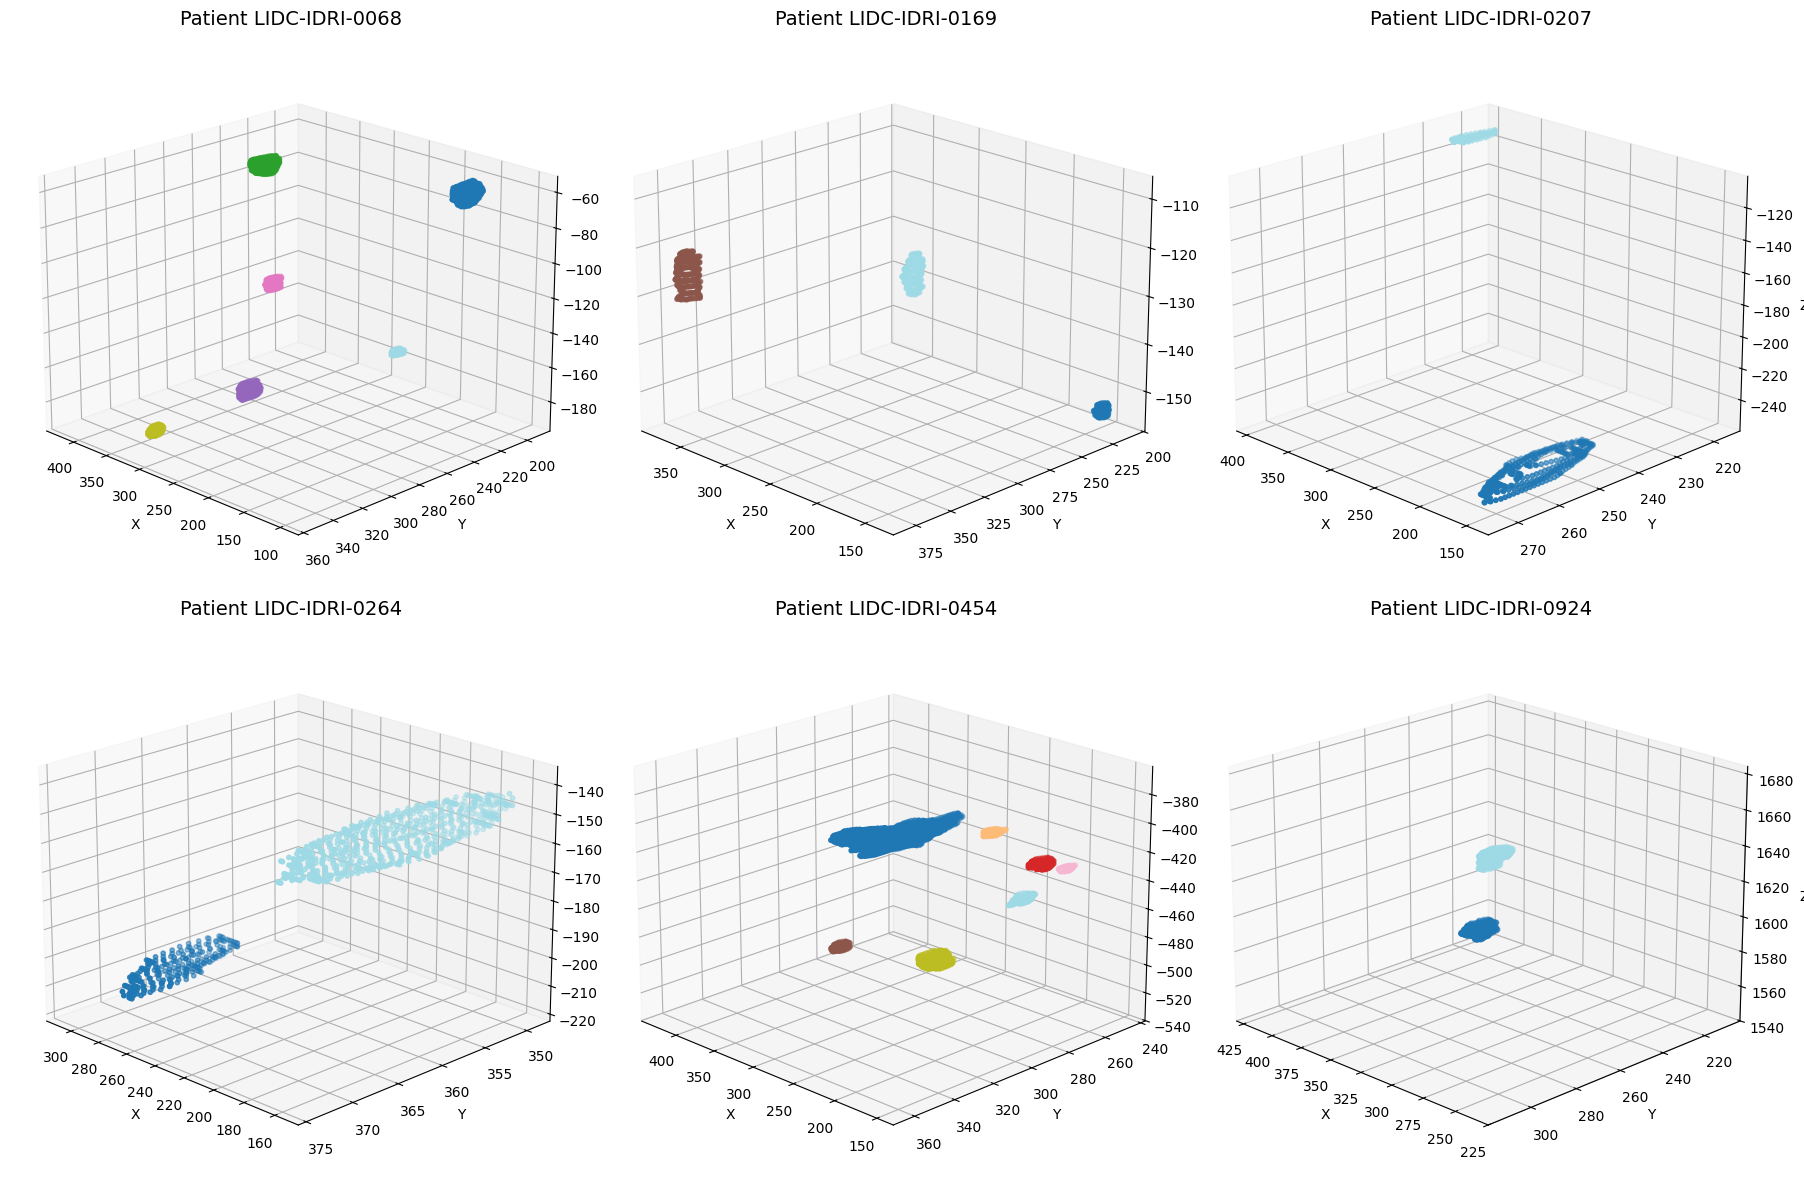

In [10]:
# Set up figure
fig = plt.figure(figsize=(18, 12))  # Wider layout for 2x3
patient_ids = df_good_clean["PatientID"].unique()
indices = [0, 20, 40, 60, 80, 100]

# Loop through and plot each tumour
for idx, i in enumerate(indices):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')  # 2 rows × 3 cols

    pid = patient_ids[i]
    ax.set_title(f"Patient {pid}", fontsize=14)

    # Update your plotting function to accept ax as argument
    plot_patient_tumours_3d(df_good_clean, pid, ax=ax)

plt.tight_layout()
plt.savefig("../plots_extension/Example_3Dtumours_2x3_grid.png", dpi=400)
plt.show()


In [11]:
run = input("Create 3D volumes? (y/n): ")

if run.lower() != 'y':
    print("Exiting without creating 3D volumes.")

else:
    print("Creating 3D volumes...")
    dicom_root = "../data/Extension/DICOM_DATA_120_PATIENTS/New_manifest/manifest-1747751008571/LIDC-IDRI"
    volume_results = []

    grouped = df_good_clean.groupby(["PatientID", "TumourID"])

    for (patient_id, tumour_id), group in tqdm(grouped, desc="Building 3D Volumes"):
        try:
            # Sort by Z and get unique slices
            group_sorted = group.sort_values("Z")
            unique_z = sorted(group_sorted["Z"].unique())
            z_to_index = {z: i for i, z in enumerate(unique_z)}

            vol_shape = (len(unique_z), 512, 512)
            image_3d = np.zeros(vol_shape, dtype=np.int16)
            mask_3d = np.zeros(vol_shape, dtype=np.uint8)

            # Load all DICOM slices for the patient once
            dicom_slices = {}
            for root, _, files in os.walk(os.path.join(dicom_root, patient_id)):
                for file in files:
                    if file.endswith(".dcm"):
                        path = os.path.join(root, file)
                        try:
                            dcm = pydicom.dcmread(path)
                            if hasattr(dcm, "SliceLocation"):
                                dicom_slices[dcm.SliceLocation] = dcm
                        except Exception as e:
                            continue

            if not dicom_slices:
                print(f"⚠️ No DICOM slices found for {patient_id}")
                continue

            # Fill arrays for this tumour
            for _, row in group_sorted.iterrows():
                z = row["Z"]
                z_idx = z_to_index[z]
                x_coords = ast.literal_eval(row["X_coords"])
                y_coords = ast.literal_eval(row["Y_coords"])

                # Get closest slice
                closest_z = min(dicom_slices.keys(), key=lambda zz: abs(zz - z))
                dcm = dicom_slices[closest_z]
                slice_array = dcm.pixel_array

                # Fill volume and mask
                rr, cc = polygon(y_coords, x_coords, shape=slice_array.shape)
                image_3d[z_idx, rr, cc] = slice_array[rr, cc]
                mask_3d[z_idx, rr, cc] = 1

            # Convert to SimpleITK images
            sitk_image = sitk.GetImageFromArray(image_3d.astype(np.float32))
            sitk_mask = sitk.GetImageFromArray(mask_3d)
            sitk_mask.CopyInformation(sitk_image)

            # Save result for Step 3
            volume_results.append({
                "PatientID": patient_id,
                "TumourID": tumour_id,
                "sitk_image": sitk_image,
                "sitk_mask": sitk_mask,
                "NumSlices": len(unique_z)
            })

        except Exception as e:
            print(f"❌ Error for {patient_id}, tumour {tumour_id}: {e}")

    # Save
    with open("volume_results.pkl", "wb") as f:
        pickle.dump(volume_results, f)


Exiting without creating 3D volumes.


### Pyradiomics Extraction for the 284 3D tumours

In [12]:
with open("../data/Extension/volume_results.pkl", "rb") as f:
    volume_results = pickle.load(f)

In [13]:
from radiomics import featureextractor
import pandas as pd
from tqdm import tqdm

# Initialize PyRadiomics with YAML settings
# extractor = featureextractor.RadiomicsFeatureExtractor("params.yaml")
extractor = featureextractor.RadiomicsFeatureExtractor()
features_list = []

for item in tqdm(volume_results, desc="Extracting radiomics"):
    try:
        patient_id = item["PatientID"]
        tumour_id = item["TumourID"]
        sitk_image = item["sitk_image"]
        sitk_mask = item["sitk_mask"]
        num_slices = item["NumSlices"]

        # Run PyRadiomics
        features = extractor.execute(sitk_image, sitk_mask)

        # Filter out diagnostic/internal fields
        features_clean = {k: v for k, v in features.items() if not k.startswith("diagnostics")}

        # Add metadata
        features_clean["PatientID"] = patient_id
        features_clean["TumourID"] = tumour_id
        features_clean["NumSlices"] = num_slices

        features_list.append(features_clean)

    except Exception as e:
        print(f"❌ Error for Patient {patient_id}, Tumour {tumour_id}: {e}")

# Create DataFrame and save
df_radiomics = pd.DataFrame(features_list)
df_radiomics.to_csv("../data/Extension/All_radiomic_features_3D.csv", index=False)
print("✅ Saved radiomics features to All_radiomics_features_3D.csv")

Extracting radiomics:   2%|▏         | 5/284 [00:01<00:51,  5.41it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Extracting radiomics:   2%|▏         | 7/284 [00:01<01:14,  3.74it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Extracting radiomics:   4%|▎         | 10/284 [00:02<00:47,  5.77it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Extracting radiomics:   8%|▊         | 22/284 [00:04<00:37,  7.04it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, 

✅ Saved radiomics features to All_radiomics_features_3D.csv


### Append Labels to this radiomic dataset

In [14]:
# Step 1: Get one label per tumour
df_labels = df_good_clean[["PatientID", "TumourID", "Label"]].drop_duplicates()

# Step 2: Check for conflicting labels per tumour
conflicts = df_labels.groupby(["PatientID", "TumourID"])["Label"].nunique()
if (conflicts > 1).any():
    print("❌ Warning: Multiple labels found for some (PatientID, TumourID) combinations.")

# Step 3: Remove duplicates safely (assuming consistent labels)
df_labels = df_labels.drop_duplicates(subset=["PatientID", "TumourID"])

# Step 4: Merge with extracted radiomics features
df_radiomics_labeled = df_radiomics.merge(df_labels, on=["PatientID", "TumourID"], how="left")

# Step 5: Check for missing labels
missing = df_radiomics_labeled["Label"].isna().sum()
if missing > 0:
    print(f"⚠️ {missing} tumours have missing labels!")

# Step 6: Convert feature columns to numeric (excluding metadata and label)
feature_cols = df_radiomics_labeled.columns.difference(["PatientID", "TumourID", "NumSlices", "Label"])
df_radiomics_labeled[feature_cols] = df_radiomics_labeled[feature_cols].apply(pd.to_numeric, errors="coerce")

# Step 7: Save final labeled DataFrame
df_radiomics_labeled.to_csv("../data/All_3D_Radiomics_labelsappended.csv", index=False)
print("✅ Final radiomics file saved with labels: ../data/All_3D_Radiomics_labelsappended.csv")


✅ Final radiomics file saved with labels: ../data/All_3D_Radiomics_labelsappended.csv


In [15]:
for col in df_radiomics_labeled.columns:
    if df_radiomics_labeled[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        df_radiomics_labeled[col] = df_radiomics_labeled[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.size == 1 else x)

In [16]:
df_radiomics_labeled.to_csv("../data/All_3D_Radiomics_labelsappended_numeric.csv", index=False)

## Machine Learning: LIDC

In [17]:
df_radiomics_labeled = pd.read_csv("../data/All_3D_Radiomics_labelsappended_numeric.csv")

### Feature Selection Part 1 (KW + Correlation)

In [18]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import pandas as pd

# 1. Prepare data
X = df_radiomics_labeled.drop(columns=["Label", "PatientID", "TumourID", "NumSlices"])
y = df_radiomics_labeled["Label"]

# 2. Perform Kruskal-Wallis test
p_values = [kruskal(X[col][y == 0], X[col][y == 1]).pvalue for col in X.columns]

# 3. FDR correction
fdr_pass, pvals_corrected, _, _ = multipletests(p_values, alpha=0.25, method="fdr_bh")

# 4. Get selected features
selected_features = X.columns[fdr_pass]
X_selected = X[selected_features]

print(f"✅ Selected {len(selected_features)} features out of {X.shape[1]} after FDR correction.")

✅ Selected 70 features out of 107 after FDR correction.


In [19]:
import pingouin as pg

# Add subject column for rm_corr (e.g. PatientID)
df_corr = df_radiomics_labeled[["PatientID"] + list(X_selected.columns)].copy()

# Compute scores from Kruskal-Wallis (already done)
scores = {feature: 1 - p for feature, p in zip(X_selected.columns, pvals_corrected) if feature in X_selected.columns}

selected_features = list(X_selected.columns)
dropped_features = set()

for i, key1 in enumerate(selected_features):
    for key2 in selected_features[i + 1:]:
        if key1 in dropped_features or key2 in dropped_features:
            continue

        try:
            result = pg.rm_corr(data=df_corr, x=key1, y=key2, subject="PatientID")
            r = result["r"].values[0]

            if r > 0.9:
                score1 = scores.get(key1, 0)
                score2 = scores.get(key2, 0)

                if score2 > score1:
                    dropped_features.add(key1)
                elif score1 > score2:
                    dropped_features.add(key2)
                else:
                    dropped_features.add(key2)

        except Exception as e:
            print(f"⚠️ Failed correlation between {key1} and {key2}: {e}")

# Final set of decorrelated features
final_features = list(set(selected_features) - dropped_features)
print(f"✅ {len(final_features)} features selected after rm_corr filtering")

# Optional: reduced feature matrix
X_filtered = df_radiomics_labeled[final_features]

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))


✅ 31 features selected after rm_corr filtering


### Feature Selection Part 2 (RFE)

✅ Optimal number of features: 30
✅ Selected features: ['original_firstorder_MeanAbsoluteDeviation', 'original_glszm_ZoneEntropy', 'original_firstorder_Minimum', 'original_glrlm_RunEntropy', 'original_glszm_GrayLevelNonUniformity', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_firstorder_Energy', 'original_glcm_JointEnergy', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_gldm_DependenceEntropy', 'original_glrlm_LongRunHighGrayLevelEmphasis', 'original_shape_Elongation', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glcm_JointEntropy', 'original_glcm_Imc1', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glcm_ClusterShade', 'original_glrlm_GrayLevelVariance', 'original_ngtdm_Coarseness', 'original_shape_SurfaceVolumeRatio', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 'original_glszm_GrayLevelNonUniformityNormalized', 'original_glszm_LowGrayLevelZoneEmphasis', 'original_shape_Sphericity',

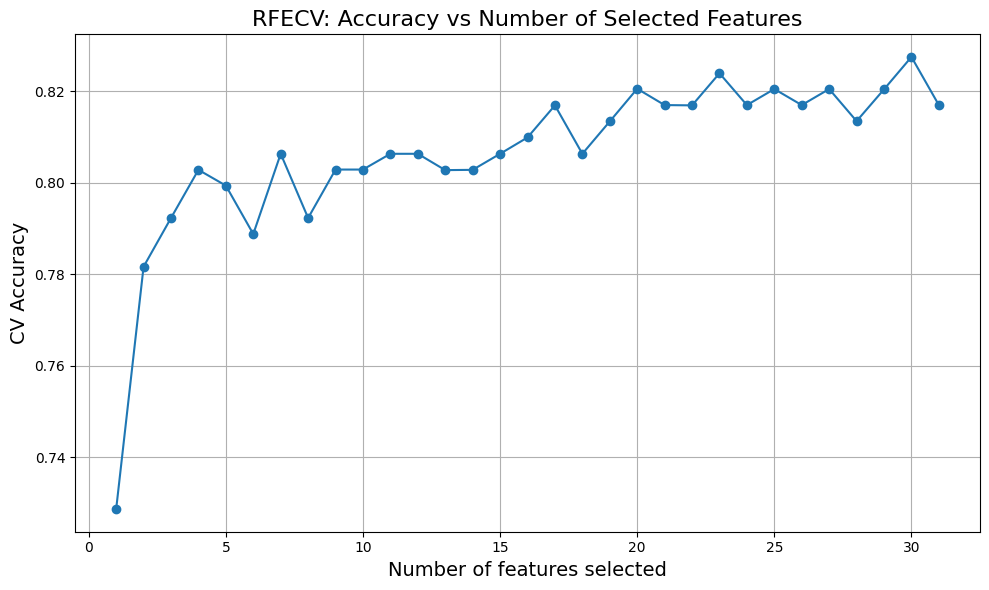

In [20]:
from sklearn.feature_selection import RFECV

y = df_radiomics_labeled["Label"]

# === Setup ===
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

# === RFE with Stratified CV ===
rfecv = RFECV(
    estimator=rf_base,
    step=1,
    cv=StratifiedKFold(5),
    scoring="accuracy",
    n_jobs=-1
)

rfecv.fit(X_filtered, y)

# === Result summary ===
print("✅ Optimal number of features:", rfecv.n_features_)
selected_mask = rfecv.support_
selected_features = X_filtered.columns[selected_mask]
print("✅ Selected features:", list(selected_features))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'],
         marker='o')
plt.xlabel("Number of features selected", fontsize=14)
plt.ylabel("CV Accuracy", fontsize=14)
plt.title("RFECV: Accuracy vs Number of Selected Features", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.savefig("../plots_extension/rfecv_accuracy_vs_features.png", dpi=300)
plt.show()

rfecv_features = X_filtered.columns[rfecv.support_].tolist()

### Feature Selection Alternative Part 2: Boruta 

In [21]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# --- Inputs (X and y) ---
X = df_radiomics_labeled[final_features].copy()
y = df_radiomics_labeled["Label"].copy()

# --- Boruta setup ---
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1
)

boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators=500,         # ✅ fixed for stability
    verbose=2,
    random_state=42,
    max_iter=100,
    alpha=0.15                # ✅ slightly less aggressive
)

# --- Fit Boruta ---
boruta_selector.fit(X.values, y.values)

# --- Get selected features (confirmed + tentative) ---
support_combined = boruta_selector.support_ | boruta_selector.support_weak_
selected_features_boruta = X.columns[support_combined].tolist()

print("✅ Selected features using Boruta (confirmed + tentative):", selected_features_boruta)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	9 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	10 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	11 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	12 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	22
Iteration: 	13 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	23
Iteration: 	14 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	23
Iteration: 	15 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	23
Iteration: 	16 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	23
I

In [22]:
# Replace this with your actual RFE-selected list
rfe_selected = rfecv.get_feature_names_out() 

# --- Compare ---
print("\n🟢 Common features:", list(set(selected_features_boruta) & set(rfe_selected)))
print("➕ Only in Boruta:", list(set(selected_features_boruta) - set(rfe_selected)))
print("➖ Only in RFE:", list(set(rfe_selected) - set(selected_features_boruta)))



🟢 Common features: ['original_firstorder_Minimum', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glszm_GrayLevelNonUniformityNormalized', 'original_glcm_JointEntropy', 'original_glszm_GrayLevelNonUniformity', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_ngtdm_Coarseness']
➕ Only in Boruta: []
➖ Only in RFE: ['original_firstorder_MeanAbsoluteDeviation', 'original_glszm_ZoneEntropy', 'original_glrlm_RunEntropy', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_firstorder_Energy', 'original_glcm_JointEnergy', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_gldm_DependenceEntropy', 'original_glrlm_LongRunHighGrayLevelEmphasis', 'original_shape_Elongation', 'original_glcm_Imc1', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glcm_ClusterShade', 'original_glrlm_GrayLevelVariance', 'original_shape_SurfaceVolumeRatio', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 'original_glszm_LowGrayLevelZoneEmphasis', 'original_shape_Sphericit

### Training ML models on this reduced dataset

In [108]:
from sklearn.model_selection import train_test_split

X = df_radiomics_labeled[rfecv_features]
y = df_radiomics_labeled["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_boruta = df_radiomics_labeled[selected_features_boruta]
X_train_boruta, X_test_boruta, y_train_boruta, y_test_boruta = train_test_split(
    X_boruta, y, test_size=0.2, stratify=y, random_state=42
)

### 1. RF (NO SMOTE)

In [144]:
pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### AUC SCORES
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
print("Cross-validated AUCs:", scores)
print("Mean AUC:", scores.mean())
scores_boruta = cross_val_score(pipeline, X_train_boruta, y_train_boruta, cv=cv, scoring="roc_auc")
print("Boruta Cross-validated AUCs:", scores_boruta)
print("Boruta Mean AUC:", scores_boruta.mean())

### RFE RESULTS

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]


print("Test AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=3))
report_rfe_rf_nosmote = classification_report(y_test, y_pred, output_dict=True)


### Boruta RESULTS

pipeline.fit(X_train_boruta, y_train_boruta)
y_pred = pipeline.predict(X_test_boruta)
y_proba = pipeline.predict_proba(X_test_boruta)[:, 1]

print("Test AUC:", roc_auc_score(y_test_boruta, y_proba))
print(classification_report(y_test_boruta, y_pred, digits=3))
report_boruta = classification_report(y_test_boruta, y_pred, output_dict=True)


Cross-validated AUCs: [0.72972973 0.62612613 0.69907407 0.7654321  0.56587838]
Mean AUC: 0.6772480814147481
Boruta Cross-validated AUCs: [0.85735736 0.64864865 0.71296296 0.78240741 0.64527027]
Boruta Mean AUC: 0.7293293293293294
Test AUC: 0.5958498023715415
              precision    recall  f1-score   support

           0      0.571     0.364     0.444        11
           1      0.860     0.935     0.896        46

    accuracy                          0.825        57
   macro avg      0.716     0.649     0.670        57
weighted avg      0.804     0.825     0.809        57

Test AUC: 0.6472332015810277
              precision    recall  f1-score   support

           0      0.429     0.273     0.333        11
           1      0.840     0.913     0.875        46

    accuracy                          0.789        57
   macro avg      0.634     0.593     0.604        57
weighted avg      0.761     0.789     0.770        57



### Apply SMOTE to balance classes

In [145]:
# Re-split if needed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

### Boruta
X_train_boruta_resampled, y_train_boruta_resampled = smote.fit_resample(X_train_boruta, y_train_boruta)
print("After SMOTE (Boruta):", pd.Series(y_train_boruta_resampled).value_counts())

After SMOTE: Label
0    183
1    183
Name: count, dtype: int64
After SMOTE (Boruta): Label
0    183
1    183
Name: count, dtype: int64


/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


### 2. RF (SMOTE)

In [94]:
### RFE results
# Train
pipeline.fit(X_train_resampled, y_train_resampled)

# Evaluate on real test data
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Metrics
from sklearn.metrics import classification_report, roc_auc_score

print("Test AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=3))
report_RF_smote = classification_report(y_test, y_pred, output_dict=True)


### Boruta results

pipeline.fit(X_train_boruta_resampled, y_train_boruta_resampled)

# Evaluate on real test data
y_pred_boruta = pipeline.predict(X_test_boruta)
y_proba_boruta = pipeline.predict_proba(X_test_boruta)[:, 1]

# Metrics
print("Test AUC (Boruta):", roc_auc_score(y_test_boruta, y_proba_boruta))
print(classification_report(y_test_boruta, y_pred_boruta, digits=3))
report_RF_boruta_smote = classification_report(y_test_boruta, y_pred_boruta, output_dict=True)

Test AUC: 0.6324110671936759
              precision    recall  f1-score   support

           0      0.294     0.455     0.357        11
           1      0.850     0.739     0.791        46

    accuracy                          0.684        57
   macro avg      0.572     0.597     0.574        57
weighted avg      0.743     0.684     0.707        57

Test AUC (Boruta): 0.624505928853755
              precision    recall  f1-score   support

           0      0.412     0.636     0.500        11
           1      0.900     0.783     0.837        46

    accuracy                          0.754        57
   macro avg      0.656     0.709     0.669        57
weighted avg      0.806     0.754     0.772        57



### Calculate Errors 

In [29]:
means_rfe, ci_rfe = bootstrap_ci(
    X_train_resampled, y_train_resampled,
    X_test, y_test,
    pipeline
)

means_rfe_boruta, ci_boruta = bootstrap_ci(
    X_train_boruta_resampled, y_train_boruta_resampled,
    X_test_boruta, y_test_boruta,
    pipeline
)

### 3. XGBOOST (SMOTE)

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
pipeline = Pipeline([
    ("scaler", StandardScaler()),  # optional
    ("model", xgb)
])

In [96]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Step 1: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 3: Train XGBoost classifier
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Step 4: Evaluate on test set
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Step 5: Print metrics
print("Test AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=3))
report_xgb_nosmote = classification_report(y_test, y_pred, output_dict=True)


### Boruta Results

xgb_model.fit(X_train_boruta_resampled, y_train_boruta_resampled)

# Evaluate on real test data
y_pred_boruta = xgb_model.predict(X_test_boruta)
y_proba_boruta = xgb_model.predict_proba(X_test_boruta)[:, 1]

# Metrics
print("Test AUC (Boruta):", roc_auc_score(y_test_boruta, y_proba_boruta))
print(classification_report(y_test_boruta, y_pred_boruta, digits=3))
report_xgb_boruta_smote = classification_report(y_test_boruta, y_pred_boruta, output_dict=True)

# XGB
# RFE version
# means_rfe_xgb, cis_rfe_xgb = bootstrap_ci(
#     X_train_resampled, y_train_resampled,
#     X_test, y_test,
#     xgb_model
# )

# # Boruta version
# means_boruta_xgb, cis_boruta_xgb = bootstrap_ci(
#     X_train_boruta_resampled, y_train_boruta_resampled,
#     X_test_boruta, y_test_boruta,
#     xgb_model
# )

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:56:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test AUC: 0.6067193675889329
              precision    recall  f1-score   support

           0      0.316     0.545     0.400        11
           1      0.868     0.717     0.786        46

    accuracy                          0.684        57
   macro avg      0.592     0.631     0.593        57
weighted avg      0.762     0.684     0.711        57

Test AUC (Boruta): 0.6521739130434783
              precision    recall  f1-score   support

           0      0.267     0.364     0.308        11
           1      0.833     0.761     0.795        46

    accuracy                          0.684        57
   macro avg      0.550     0.562     0.552        57
weighted avg      0.724     0.684     0.701        57



/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:56:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### Grid search for better xgboost params

In [97]:
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Create a custom scoring function for recall of class 0
recall_class_0 = make_scorer(recall_score, pos_label=0)

params = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9],
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='auc', random_state=42, use_label_encoder=False),
    param_grid=params,
    scoring=recall_class_0,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_resampled, y_train_resampled)

print("✅ Best Recall for Class 0:", grid.best_score_)
print("✅ Best Params:", grid.best_params_)

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:56:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:56:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:56:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:56:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_lab

✅ Best Recall for Class 0: 0.9294294294294294
✅ Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}


### Re-attempt of xgboost

In [99]:
# Final XGBoost model with tuned parameters
best_xgb = XGBClassifier(
    max_depth=grid.best_params_['max_depth'],
    n_estimators=grid.best_params_['n_estimators'],
    learning_rate=grid.best_params_['learning_rate'],
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False
)

# Fit on SMOTE-resampled training data
best_xgb.fit(X_train_resampled, y_train_resampled)

# Predict on original test set
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("Test AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=3))
report_xgb_nosmote = classification_report(y_test, y_pred, output_dict=True)

### Boruta Results
best_xgb.fit(X_train_boruta_resampled, y_train_boruta_resampled)

# Predict on original test set
y_pred_boruta = best_xgb.predict(X_test_boruta)
y_proba_boruta = best_xgb.predict_proba(X_test_boruta)[:, 1]

# Evaluate
print("Test AUC (Boruta):", roc_auc_score(y_test_boruta, y_proba_boruta))
print(classification_report(y_test_boruta, y_pred_boruta, digits=3))
report_xgb_boruta_smote = classification_report(y_test_boruta, y_pred_boruta, output_dict=True)

means_rfe_xgb, cis_rfe_xgb = bootstrap_ci(
    X_train_resampled, y_train_resampled,
    X_test, y_test,
    best_xgb
)

# Boruta version
means_boruta_xgb, cis_boruta_xgb = bootstrap_ci(
    X_train_boruta_resampled, y_train_boruta_resampled,
    X_test_boruta, y_test_boruta,
    best_xgb
)

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:59:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test AUC: 0.6067193675889329
              precision    recall  f1-score   support

           0      0.333     0.545     0.414        11
           1      0.872     0.739     0.800        46

    accuracy                          0.702        57
   macro avg      0.603     0.642     0.607        57
weighted avg      0.768     0.702     0.725        57



/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:59:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test AUC (Boruta): 0.66600790513834
              precision    recall  f1-score   support

           0      0.312     0.455     0.370        11
           1      0.854     0.761     0.805        46

    accuracy                          0.702        57
   macro avg      0.583     0.608     0.587        57
weighted avg      0.749     0.702     0.721        57



/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:59:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:59:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:59:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:59:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_lab

### 4. Logisitc Regressor (SMOTE)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# --- Build pipeline ---
logreg_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# --- Fit on SMOTE-resampled training data (RFE features) ---
logreg_pipeline.fit(X_train_resampled, y_train_resampled)

# --- Predict on original test set ---
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

# --- Evaluate ---
print("Test AUC (LogReg RFE):", roc_auc_score(y_test, y_proba_logreg))
report_logreg_rfe = classification_report(y_test, y_pred_logreg, digits=3, output_dict=True)
print(classification_report(y_test, y_pred_logreg, digits=3))
report_log_rfe = classification_report(y_test, y_pred_logreg, output_dict=True)


### Boruta Results

logreg_pipeline.fit(X_train_boruta_resampled, y_train_boruta_resampled)

# --- Predict on original test set ---
y_pred_logreg_boruta = logreg_pipeline.predict(X_test_boruta)
y_proba_logreg_boruta = logreg_pipeline.predict_proba(X_test_boruta)[:, 1]

# --- Evaluate ---
print("Test AUC (LogReg Boruta):", roc_auc_score(y_test_boruta, y_proba_logreg_boruta))
print(classification_report(y_test_boruta, y_pred_logreg_boruta, digits=3))
report_logreg_boruta = classification_report(y_test_boruta, y_pred_logreg_boruta, digits=3, output_dict=True)


# RFE version
means_rfe_log, cis_rfe_log = bootstrap_ci(
    X_train_resampled, y_train_resampled,
    X_test, y_test,
    logreg_pipeline
)

# Boruta version
means_boruta_log, cis_boruta_log = bootstrap_ci(
    X_train_boruta_resampled, y_train_boruta_resampled,
    X_test_boruta, y_test_boruta,
    logreg_pipeline
)

Test AUC (LogReg RFE): 0.6007905138339922
              precision    recall  f1-score   support

           0      0.222     0.364     0.276        11
           1      0.821     0.696     0.753        46

    accuracy                          0.632        57
   macro avg      0.521     0.530     0.514        57
weighted avg      0.705     0.632     0.661        57

Test AUC (LogReg Boruta): 0.5652173913043479
              precision    recall  f1-score   support

           0      0.222     0.545     0.316        11
           1      0.833     0.543     0.658        46

    accuracy                          0.544        57
   macro avg      0.528     0.544     0.487        57
weighted avg      0.715     0.544     0.592        57



### 5. SVM (SMOTE)

In [35]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# === RFE: Build SVM pipeline ===
svm_pipeline_rfe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", SVC(probability=True, class_weight="balanced", random_state=42))
])

# --- Fit on SMOTE-resampled training data (RFE features) ---
svm_pipeline_rfe.fit(X_train_resampled, y_train_resampled)

# --- Predict on original test set ---
y_pred_svm_rfe = svm_pipeline_rfe.predict(X_test)
y_proba_svm_rfe = svm_pipeline_rfe.predict_proba(X_test)[:, 1]

# --- Evaluate ---
print("Test AUC (SVM RFE):", roc_auc_score(y_test, y_proba_svm_rfe))
print(classification_report(y_test, y_pred_svm_rfe, digits=3))
report_svm_rfe = classification_report(y_test, y_pred_svm_rfe, output_dict=True)

# === BORUTA: Build SVM pipeline ===
svm_pipeline_boruta = Pipeline([
    ("scale", StandardScaler()),
    ("clf", SVC(probability=True, class_weight="balanced", random_state=42))
])

# --- Fit on SMOTE-resampled training data (Boruta features) ---
svm_pipeline_boruta.fit(X_train_boruta_resampled, y_train_boruta_resampled)

# --- Predict on original test set ---
y_pred_svm_boruta = svm_pipeline_boruta.predict(X_test_boruta)
y_proba_svm_boruta = svm_pipeline_boruta.predict_proba(X_test_boruta)[:, 1]

# --- Evaluate ---
print("Test AUC (SVM Boruta):", roc_auc_score(y_test_boruta, y_proba_svm_boruta))
print(classification_report(y_test_boruta, y_pred_svm_boruta, digits=3))
report_svm_boruta = classification_report(y_test_boruta, y_pred_svm_boruta, output_dict=True)


Test AUC (SVM RFE): 0.6324110671936759
              precision    recall  f1-score   support

           0      0.350     0.636     0.452        11
           1      0.892     0.717     0.795        46

    accuracy                          0.702        57
   macro avg      0.621     0.677     0.623        57
weighted avg      0.787     0.702     0.729        57

Test AUC (SVM Boruta): 0.6027667984189724
              precision    recall  f1-score   support

           0      0.250     0.455     0.323        11
           1      0.838     0.674     0.747        46

    accuracy                          0.632        57
   macro avg      0.544     0.564     0.535        57
weighted avg      0.724     0.632     0.665        57



In [36]:
# RFE version
means_rfe_svm, cis_rfe_svm = bootstrap_ci(
    X_train_resampled, y_train_resampled,
    X_test, y_test,
    svm_pipeline_rfe
)

# Boruta version
means_boruta_svm, cis_boruta_svm = bootstrap_ci(
    X_train_boruta_resampled, y_train_boruta_resampled,
    X_test_boruta, y_test_boruta,
    svm_pipeline_boruta
)

### SHAP ANALYSIS FULL DATASET (RF)

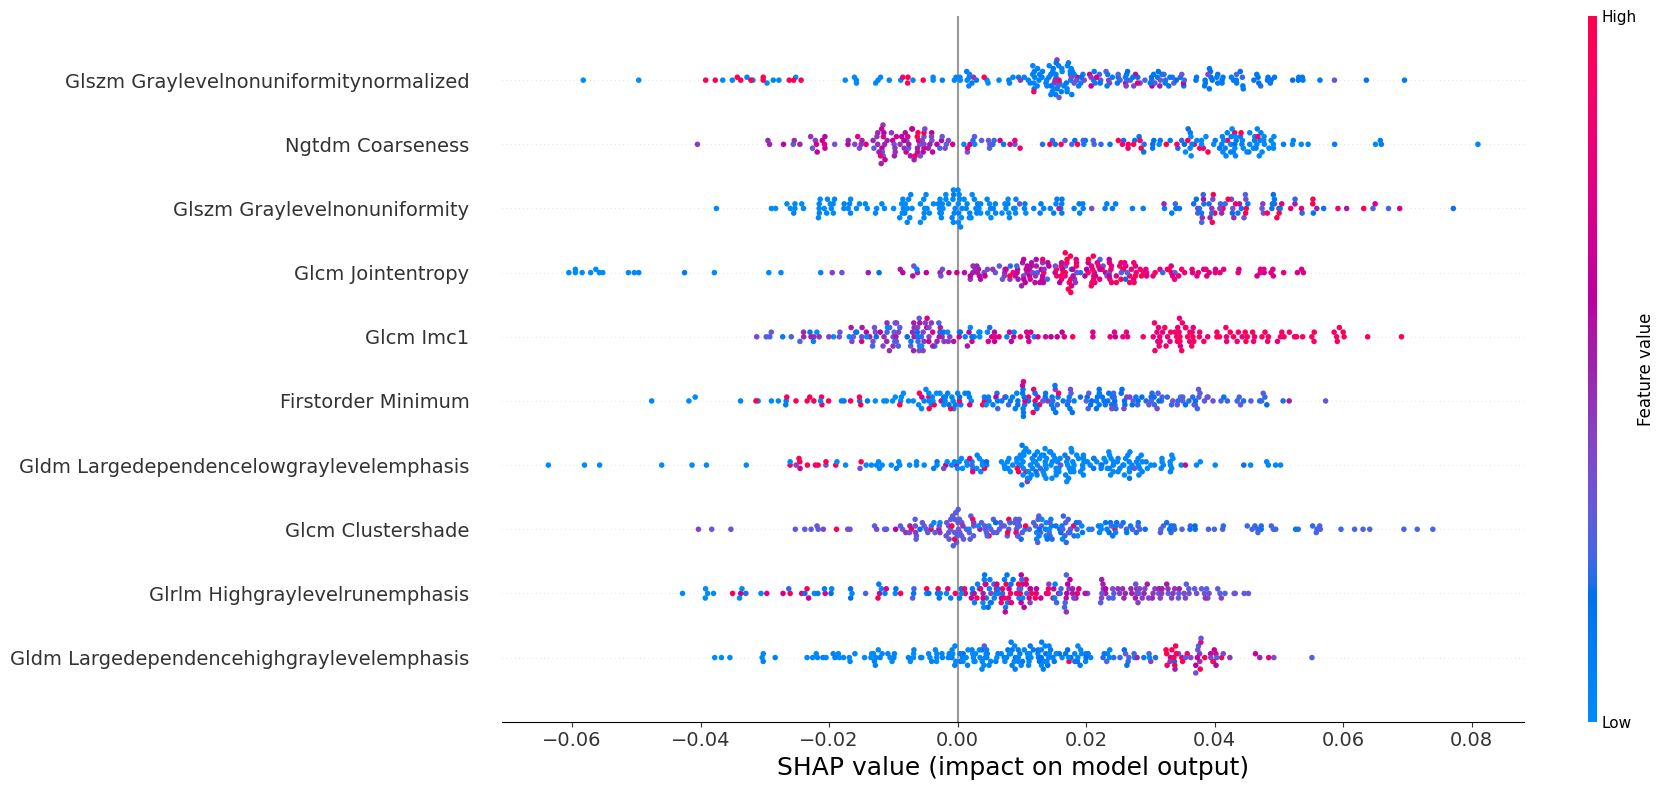

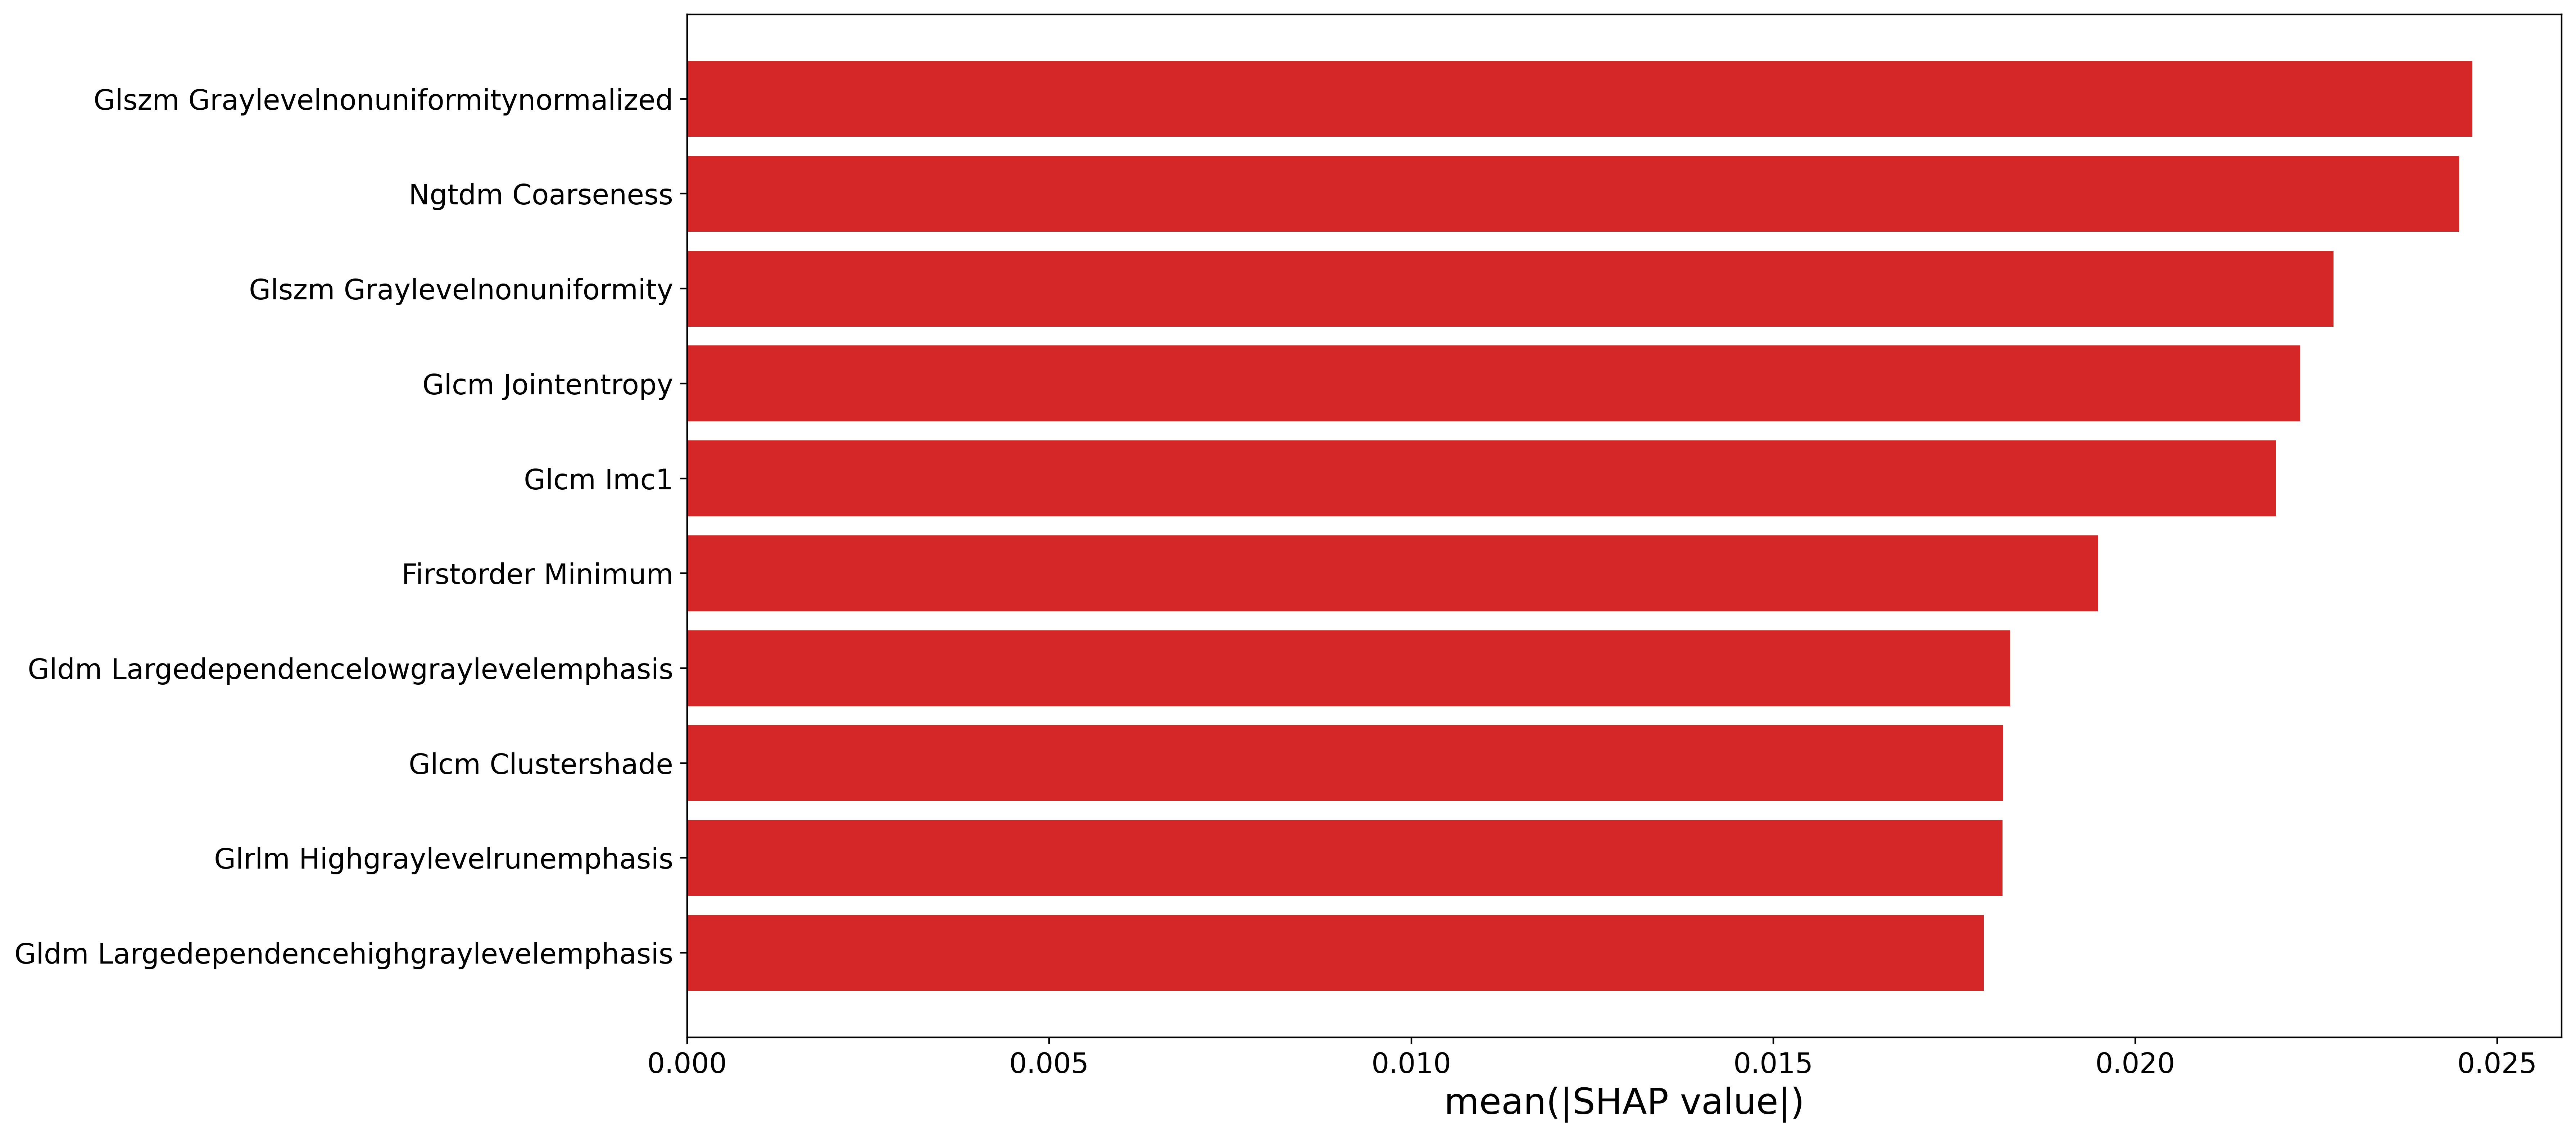

In [121]:
# Define and fit the pipeline
pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

# Extract the trained model
rf = pipeline.named_steps['clf']
scaler = pipeline.named_steps['scale']

X_transformed = scaler.transform(X_train)

# Choose data to explain
X_to_explain = X_train

# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)
shap_values_class1 = shap_values[:, :, 1]

friendly_names = get_friendly_feature_names(X_to_explain.columns)

# BEESWARM PLOT (fully SHAP native with friendly feature names)
shap.summary_plot(
    shap_values_class1,
    X_transformed,
    feature_names=friendly_names,
    plot_size=(18, 8),
    max_display=10,
    show=False
)

plt.xlabel("SHAP value (impact on model output)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig("../plots_extension/shap_beeswarm_full.png", dpi=400)
plt.show()

# BAR PLOT (fully manual, with friendly names applied)
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-10:][::-1]
top_features = [friendly_names[i] for i in top_indices]
top_values = mean_abs_shap[top_indices]

plt.figure(figsize=(18, 8), dpi=400)
plt.barh(range(len(top_features)), top_values, color="#d62728")

plt.yticks(range(len(top_features)), top_features, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("mean(|SHAP value|)", fontsize=18)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("../plots_extension/shap_bar_full.png", dpi=400)
plt.show()


### SHAP ANALYSIS SMOTE DATASET (RF)

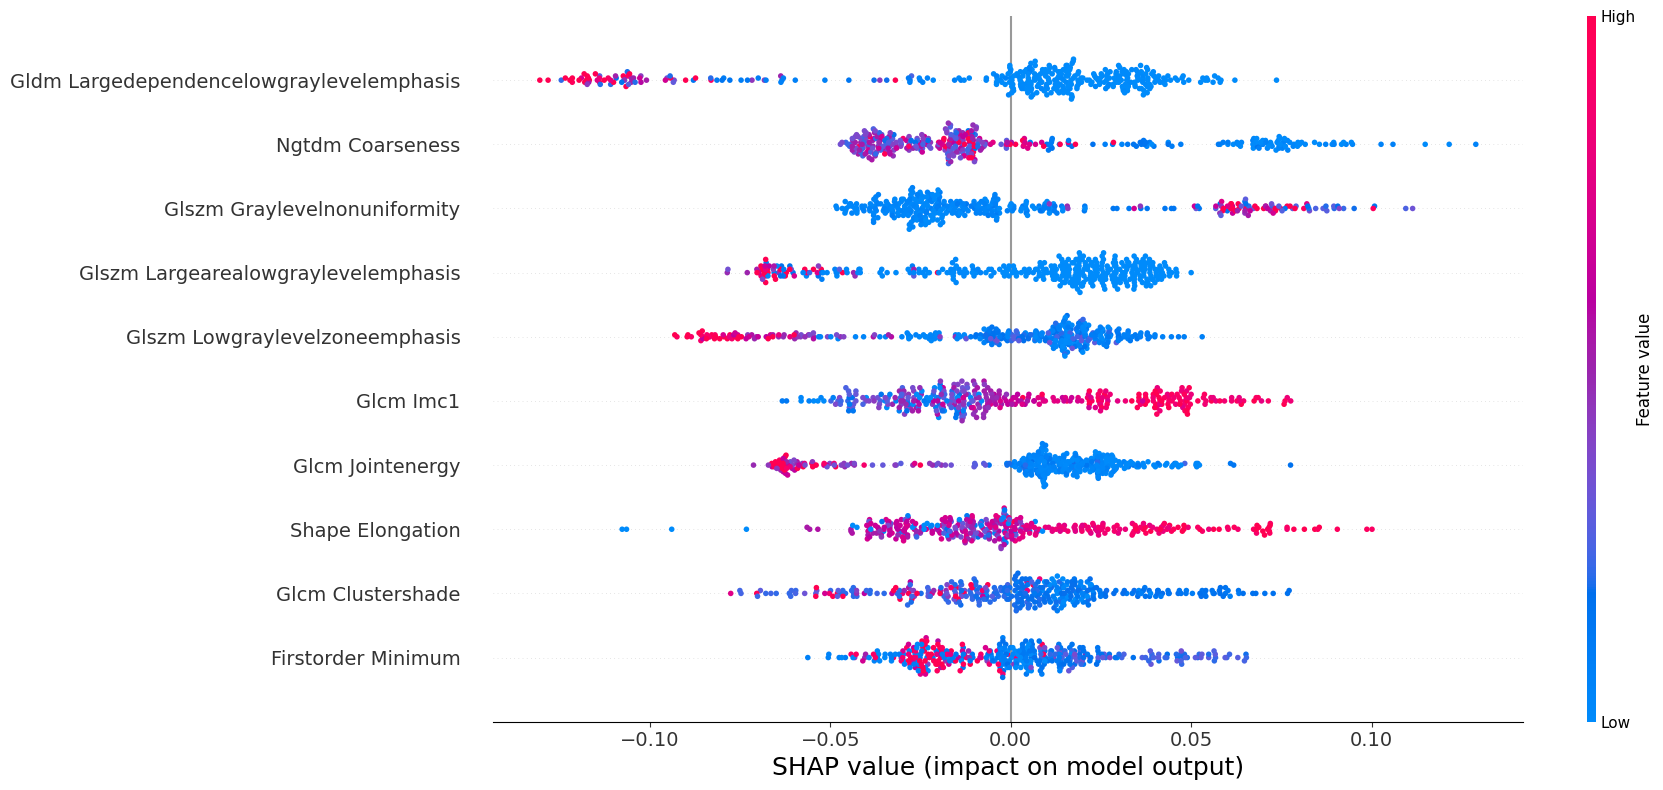

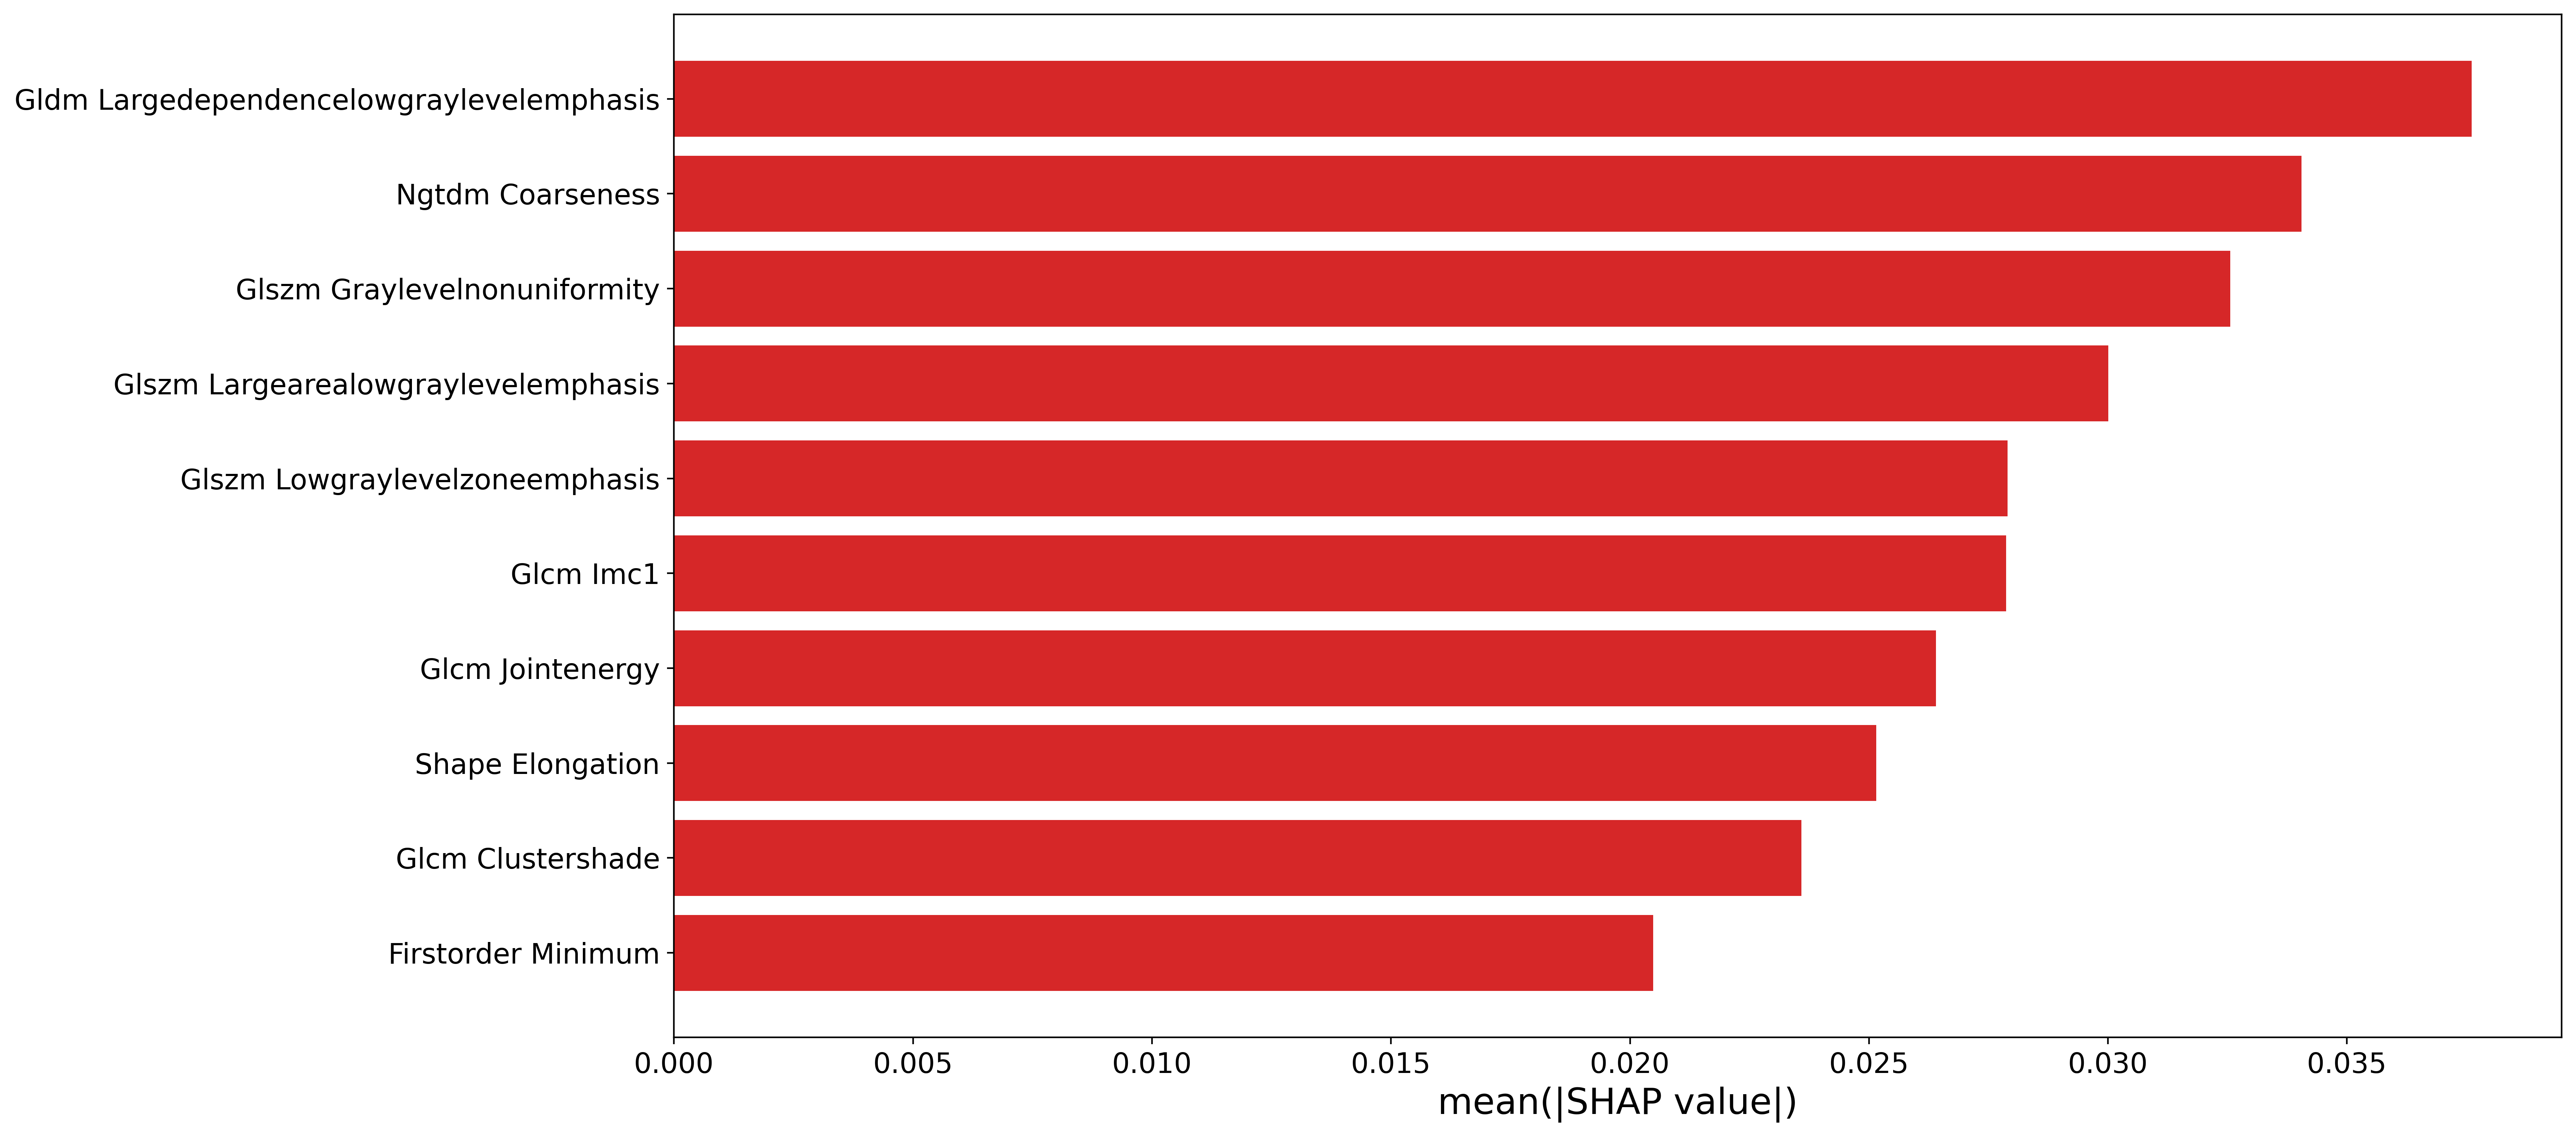

In [120]:
# Define and fit the pipeline
pipeline.fit(X_train_resampled, y_train_resampled)

# Extract the trained model
rf = pipeline.named_steps['clf']
scaler = pipeline.named_steps['scale']

X_transformed = scaler.transform(X_train_resampled)

# Choose data to explain
X_to_explain = X_train_resampled

# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)
shap_values_class1 = shap_values[:, :, 1]

friendly_names = get_friendly_feature_names(X_to_explain.columns)


# BEESWARM PLOT (fully SHAP native with friendly feature names)
shap.summary_plot(
    shap_values_class1,
    X_transformed,
    feature_names=friendly_names,
    plot_size=(18, 8),
    max_display=10,
    show=False
)

plt.xlabel("SHAP value (impact on model output)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig("../plots_extension/shap_beeswarm_SMOTE.png", dpi=400)
plt.show()

# BAR PLOT (fully manual, with friendly names applied)
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-10:][::-1]
top_features = [friendly_names[i] for i in top_indices]
top_values = mean_abs_shap[top_indices]

plt.figure(figsize=(18, 8), dpi=400)
plt.barh(range(len(top_features)), top_values, color="#d62728")

plt.yticks(range(len(top_features)), top_features, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("mean(|SHAP value|)", fontsize=18)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("../plots_extension/shap_bar_SMOTE.png", dpi=400)
plt.show()


### Extra Analysis Plots

### Venn of features

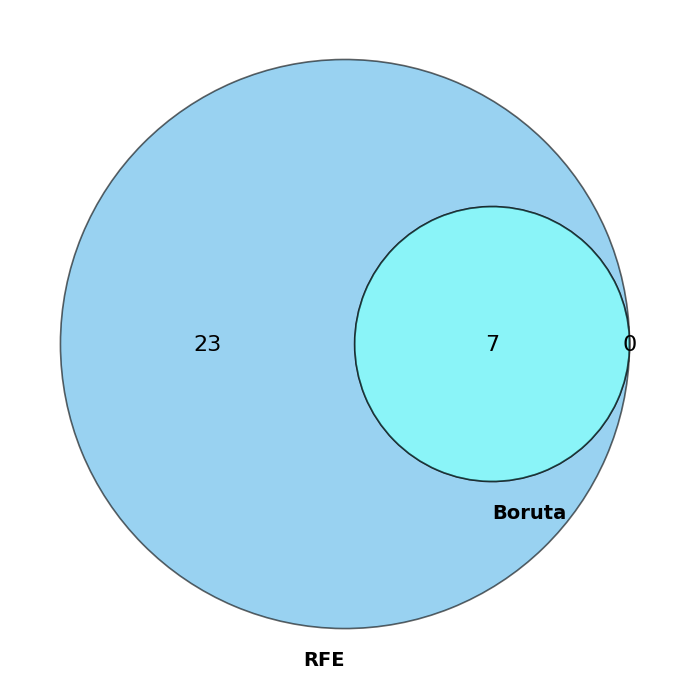

In [39]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Convert to sets
rfe_set = set(rfe_selected)
boruta_set = set(selected_features_boruta)

# Compute counts
only_rfe = len(rfe_set - boruta_set)
only_boruta = len(boruta_set - rfe_set)
both = len(rfe_set & boruta_set)

# Plot
plt.figure(figsize=(7, 7))

v = venn2([rfe_set, boruta_set], set_labels=("RFE", "Boruta"), set_colors=("#56B4E9", "#009E73"), alpha=0.6)

# Optional: manually tweak font sizes and labels
for text in v.set_labels:
    text.set_fontsize(14)
    text.set_fontweight("bold")

for text in v.subset_labels:
    if text:
        text.set_fontsize(16)

# Optional: bold edges
for patch in v.patches:
    if patch:
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)

# plt.title(f"Overlap of Selected Features\n(RFE ∩ Boruta = {both})", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots_extension/venn_rfe_boruta_improved.png", dpi=400)
plt.show()


### RFE vs Boruta Feature Selection Performance

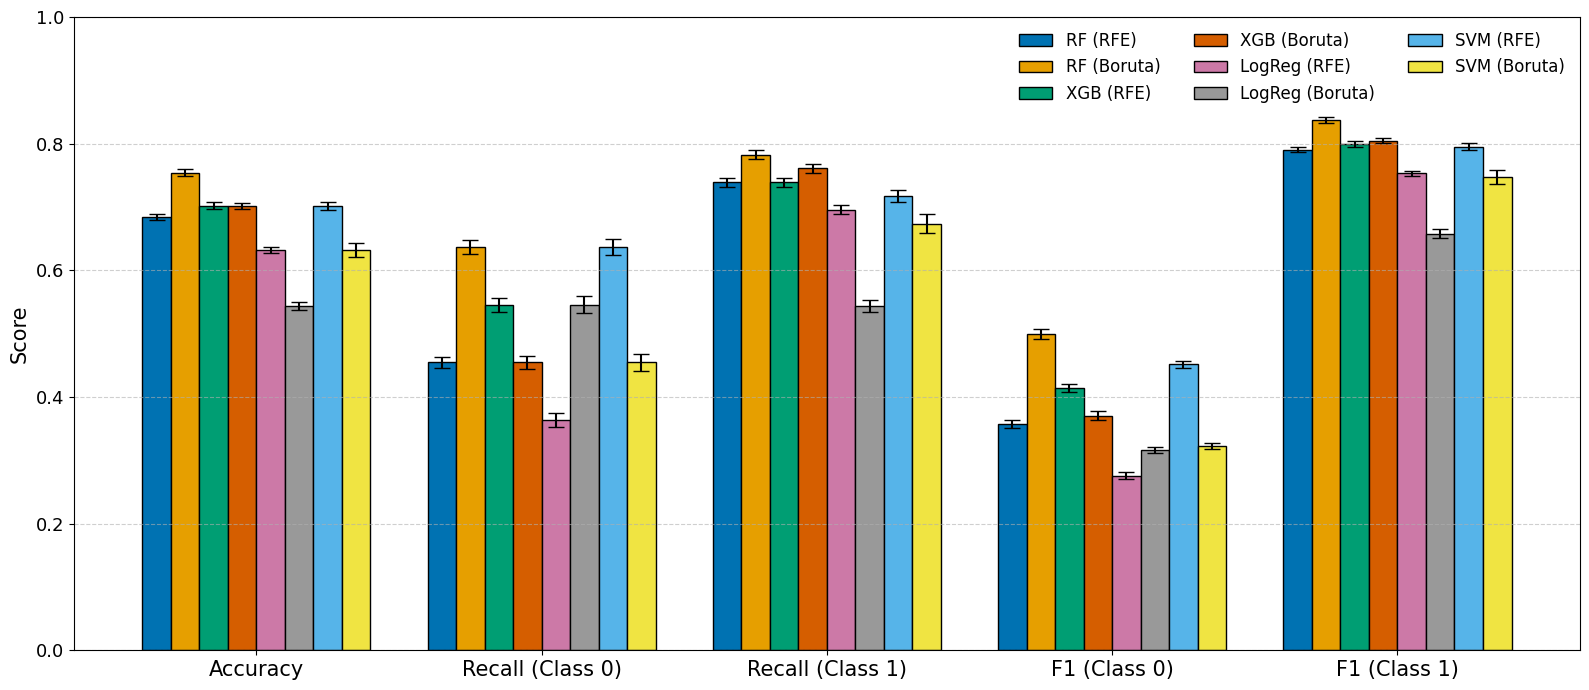

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# === Metric Labels ===
metrics = ["accuracy", "recall_class_0", "recall_class_1", "f1_class_0", "f1_class_1"]

# Extract metrics
metrics = [
    "accuracy",
    "recall_class_0",
    "recall_class_1",
    "f1_class_0",
    "f1_class_1",
]

rfe_scores = [
    report_RF_smote["accuracy"],
    report_RF_smote["0"]["recall"],
    report_RF_smote["1"]["recall"],
    report_RF_smote["0"]["f1-score"],
    report_RF_smote["1"]["f1-score"],
]

boruta_scores = [
    report_RF_boruta_smote["accuracy"],
    report_RF_boruta_smote["0"]["recall"],
    report_RF_boruta_smote["1"]["recall"],
    report_RF_boruta_smote["0"]["f1-score"],
    report_RF_boruta_smote["1"]["f1-score"],
]

rfe_scores_xgb = [
    report_xgb_nosmote["accuracy"],
    report_xgb_nosmote["0"]["recall"],
    report_xgb_nosmote["1"]["recall"],
    report_xgb_nosmote["0"]["f1-score"],
    report_xgb_nosmote["1"]["f1-score"],
]

boruta_scores_xgb = [
    report_xgb_boruta_smote["accuracy"],
    report_xgb_boruta_smote["0"]["recall"],
    report_xgb_boruta_smote["1"]["recall"],
    report_xgb_boruta_smote["0"]["f1-score"],
    report_xgb_boruta_smote["1"]["f1-score"],
]

rfe_scores_logisitic = [
    report_log_rfe["accuracy"],
    report_log_rfe["0"]["recall"],
    report_log_rfe["1"]["recall"],
    report_log_rfe["0"]["f1-score"],
    report_log_rfe["1"]["f1-score"],
]

boruta_scores_logistic = [
    report_logreg_boruta["accuracy"],
    report_logreg_boruta["0"]["recall"],
    report_logreg_boruta["1"]["recall"],
    report_logreg_boruta["0"]["f1-score"],
    report_logreg_boruta["1"]["f1-score"],
]

rfe_scores_svm = [
    report_svm_rfe["accuracy"],
    report_svm_rfe["0"]["recall"],
    report_svm_rfe["1"]["recall"],
    report_svm_rfe["0"]["f1-score"],
    report_svm_rfe["1"]["f1-score"],
]

boruta_scores_svm = [
    report_svm_boruta["accuracy"],
    report_svm_boruta["0"]["recall"],
    report_svm_boruta["1"]["recall"],
    report_svm_boruta["0"]["f1-score"],
    report_svm_boruta["1"]["f1-score"],
]


# === Metrics ===
metrics = [
    "accuracy",
    "recall_class_0",
    "recall_class_1",
    "f1_class_0",
    "f1_class_1",
]

# === Scores (from classification_report dicts) ===
rfe_rf = rfe_scores
boruta_rf = boruta_scores
rfe_xgb = rfe_scores_xgb
boruta_xgb = boruta_scores_xgb
rfe_logistic = rfe_scores_logisitic
boruta_logistic = boruta_scores_logistic
rfe_svm = rfe_scores_svm
boruta_svm = boruta_scores_svm


# === Confidence Intervals (CI values from bootstrap_ci) ===
# Replace these with your actual `cis_...` arrays from your runs
# These should all be 5-element arrays of ± error

ci_rfe_rf = ci_rfe
ci_boruta_rf = ci_boruta
ci_rfe_xgb = cis_rfe_xgb
ci_boruta_xgb = cis_boruta_xgb
ci_rfe_log = cis_rfe_log
ci_boruta_log = cis_boruta_log
ci_rfe_svm = cis_rfe_svm
ci_boruta_svm = cis_boruta_svm

# === Setup ===
x = np.arange(len(metrics))
width = 0.10

# Colorblind-friendly palette
colors = [
    "#0072B2", "#E69F00",  # RF
    "#009E73", "#D55E00",  # XGB
    "#CC79A7", "#999999",  # LogReg
    "#56B4E9", "#F0E442"   # SVM
]

labels = [
    "RF (RFE)", "RF (Boruta)",
    "XGB (RFE)", "XGB (Boruta)",
    "LogReg (RFE)", "LogReg (Boruta)",
    "SVM (RFE)", "SVM (Boruta)"
]

bar_sets = [
    (rfe_rf, ci_rfe_rf),
    (boruta_rf, ci_boruta_rf),
    (rfe_xgb, ci_rfe_xgb),
    (boruta_xgb, ci_boruta_xgb),
    (rfe_logistic, ci_rfe_log),
    (boruta_logistic, ci_boruta_log),
    (rfe_svm, ci_rfe_svm),
    (boruta_svm, ci_boruta_svm)
]

# === Plot ===
plt.figure(figsize=(16, 7))

for i, ((scores, errors), color, label) in enumerate(zip(bar_sets, colors, labels)):
    plt.bar(
        x + (i - 3.5) * width, scores, width,
        yerr=errors,
        capsize=6,        # Increased capsize
        linewidth=1.0,    # Thicker error bar line
        edgecolor='black',
        color=color,
        label=label
    )

# === Formatting ===
plt.xticks(x, ["Accuracy", "Recall (Class 0)", "Recall (Class 1)", "F1 (Class 0)", "F1 (Class 1)"], fontsize=15)
plt.yticks(fontsize=13)
plt.ylabel("Score", fontsize=15)
plt.ylim(0, 1.0)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(ncol=3, fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("../plots_extension/feature_selection_comparison_improved.png", dpi=400)
plt.show()

### SHAP CONSISTENCY ACROSS MULTIPLE SEEDS (RUNS)

/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_62639/3740739060.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


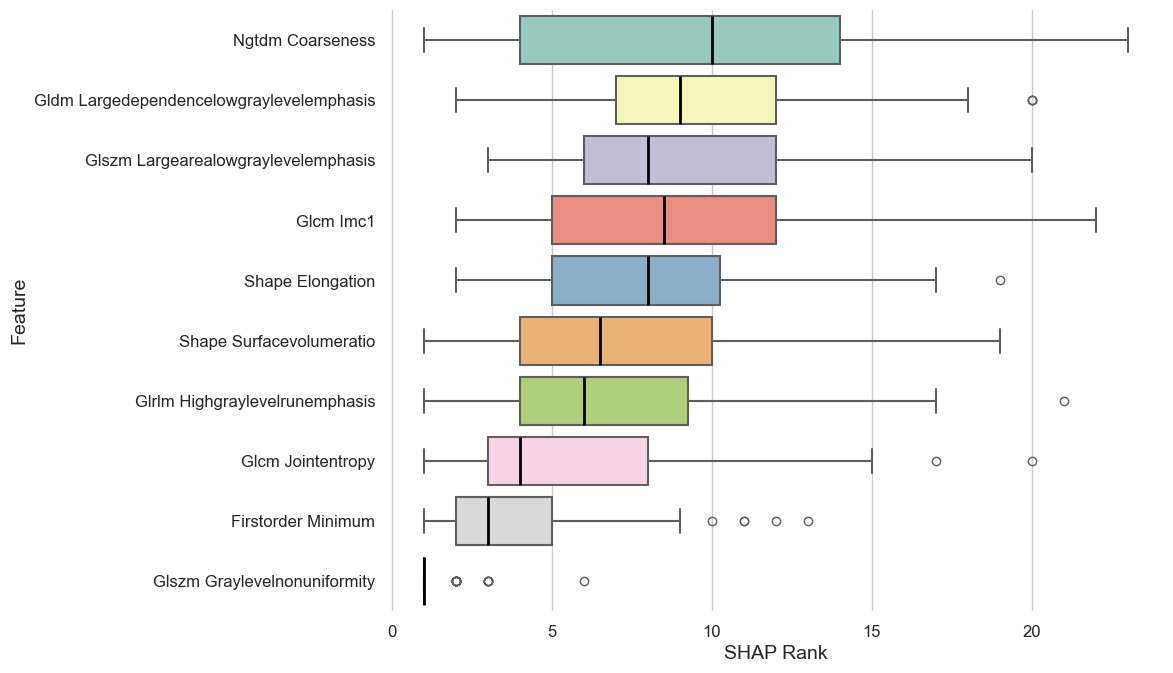

In [146]:
import numpy as np
import pandas as pd
import shap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# === Settings ===
n_seeds = 100
top_k = 10

# === Storage for ranks ===
shap_ranks = pd.DataFrame(index=X_train.columns)

# === Run SHAP multiple times ===
for seed in range(n_seeds):
    # Define and fit pipeline
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1
        ))
    ])
    
    pipe.fit(X_train, y_train)
    rf = pipe.named_steps["clf"]
    scaler = pipe.named_steps["scale"]
    X_scaled = scaler.transform(X_train)
    
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_scaled)
    shap_vals_class1 = shap_vals[:, :, 1]
    
    # Compute mean(|SHAP|) per feature
    mean_abs_shap = np.abs(shap_vals_class1).mean(axis=0)
    ranks = pd.Series((-mean_abs_shap).argsort().argsort() + 1, index=X_train.columns)
    shap_ranks[f"seed_{seed}"] = ranks

# === Friendly name conversion ===
friendly_names_dict = dict(zip(X_train.columns, get_friendly_feature_names(X_train.columns)))
shap_ranks_named = shap_ranks.rename(index=friendly_names_dict)

# === Select top 10 by average rank ===
top_features = shap_ranks_named.mean(axis=1).nsmallest(top_k).index
shap_ranks_top10 = shap_ranks_named.loc[top_features]
shap_ranks_top10 = shap_ranks_top10.loc[top_features[::-1]]  # reverse for plotting

# === Prepare for seaborn boxplot ===
df_plot = shap_ranks_top10.T.melt(var_name="Feature", value_name="Rank")

# === Plot horizontal boxplot ===
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid", font_scale=1.3)

boxprops = dict(linewidth=1.5)
medianprops = dict(linewidth=2, color='black')
whiskerprops = dict(linewidth=1.5)
capprops = dict(linewidth=1.5)
palette = sns.color_palette("Set3", n_colors=top_k)

sns.boxplot(
    data=df_plot,
    x="Rank", y="Feature",
    palette=palette,
    linewidth=1.5,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops
)

plt.xlabel("SHAP Rank", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("../plots_extension/shap_rank_stability_horizontal.png", dpi=400)
plt.show()
